For Fig. 2H

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(stringr)
    library(Seurat)
    library(dplyr)
    library(Matrix)
    library(showtext)
    library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100)

In [2]:
#Smart-seq3 data (50k reads)
WD <- "data/"
Smartseq3 <- readRDS(paste0(WD, "filtered_counts_Smartseq3_50000.rds"))
Smartseq3

An object of class Seurat 
30924 features across 80 samples within 1 assay 
Active assay: RNA (30924 features, 0 variable features)
 1 layer present: counts

In [3]:
#SELECT-seq data (200k reads)
WD <- "data/"
SELECTseq <- readRDS(paste0(WD, "filtered_counts_SELECTseq_200000.rds"))
SELECTseq

An object of class Seurat 
31360 features across 245 samples within 1 assay 
Active assay: RNA (31360 features, 0 variable features)
 1 layer present: counts

In [4]:
#combine both data sets

adata <- merge(Smartseq3, y = SELECTseq)
adata <- JoinLayers(adata)
adata

An object of class Seurat 
34268 features across 325 samples within 1 assay 
Active assay: RNA (34268 features, 0 variable features)
 1 layer present: counts

In [5]:
#remove PIK3CA gene because its expression is likely affected by targeted primers.
x <- c('PIK3CA')
adata <- subset(adata,features=setdiff(rownames(adata),x))
adata

An object of class Seurat 
34267 features across 325 samples within 1 assay 
Active assay: RNA (34267 features, 0 variable features)
 1 layer present: counts

In [6]:
adata <- NormalizeData(adata)

Normalizing layer: counts



Finding variable features for layer counts

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.5366”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.50182”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  2.49e-15”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.090619”
When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“ggrepel: 8 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


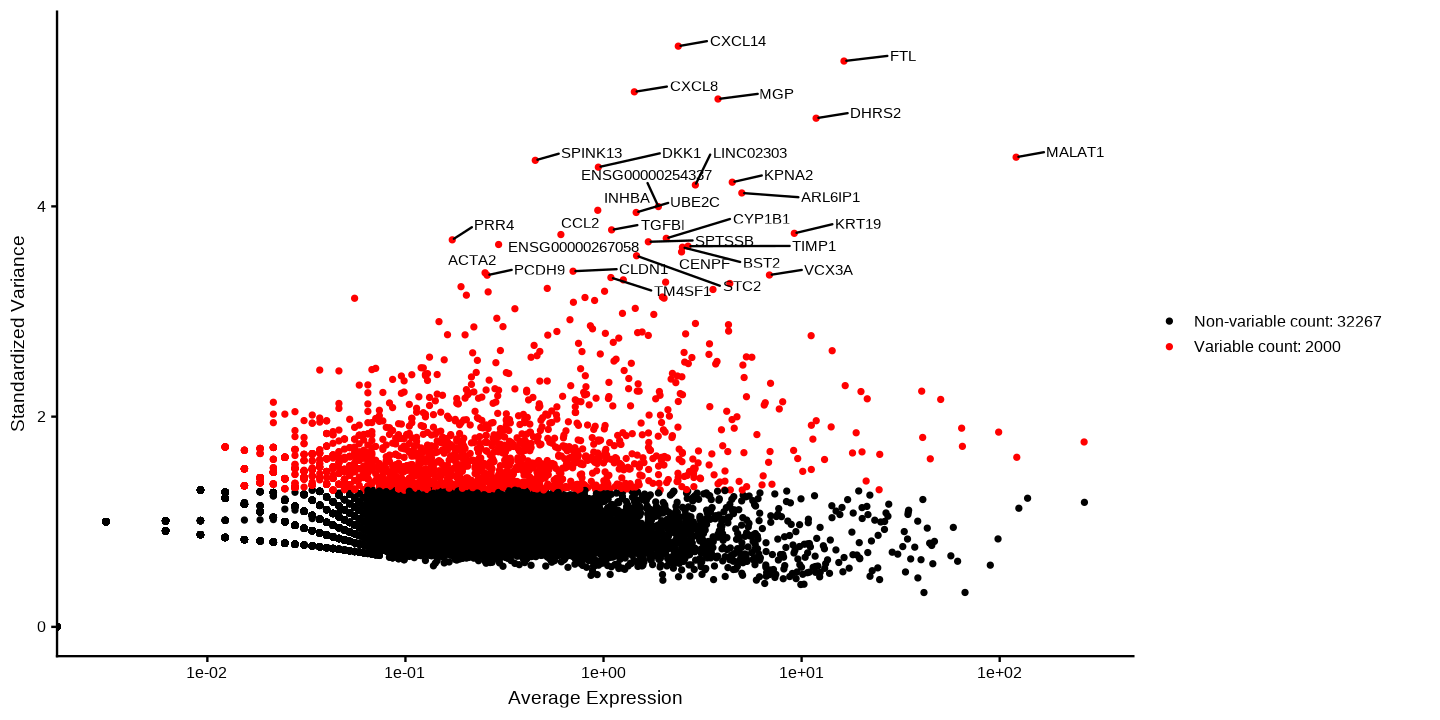

In [7]:
options(repr.plot.width = 12, repr.plot.height =6) 
adata <- FindVariableFeatures(adata, selection.method = "vst", nfeatures = 2000)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(adata), 30)

# plot variable features with and without labels
plot1 <- VariableFeaturePlot(adata)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot2

In [8]:
adata <- ScaleData(adata)
adata <- RunPCA(adata, features = VariableFeatures(object = adata))

Centering and scaling data matrix

PC_ 1 
Positive:  KRT19, VCX, DSCAM-AS1, AGR2, VCX3A, GSTM3, CLIC3, CD24, EDN1, RAB25 
	   KRT8, SNHG5, LINC02303, MGST1, VAMP8, REEP5, MGP, PGR, NDUFB5, SERPINA6 
	   KRT18, ENSG00000254337, CYP1B1, SPINT2, PRLR, XAGE2, SPTSSB, PRXL2A, DSTN, VCX3B 
Negative:  VIM, GSTP1, MIR4435-2HG, DHRS2, SPARC, GAPDH, EGR1, ANXA2, EMP1, AXL 
	   MAGEA4, PRAME, ITGB1, TPM4, OCIAD2, DUXAP10, TIMP1, NNMT, FTL, IL18 
	   TPI1, ANXA5, HAPLN1, CCND2, DUXAP8, MFGE8, KRT17, MIDEAS, PKM, GLRX 
PC_ 2 
Positive:  SUN3, MT2A, MT1E, GSTP1, ENSG00000290032, GAPDH, CRYAB, PAGE2, H2BC12, H1-2 
	   OCIAD2, TMSB15A, TNNC1, ANXA2, GLRX, RPS27L, TRAPPC6A, EGR1, H4C3, VIM 
	   IFITM3, CSRP2, LINC02802, CASC8, BEX1, MAGOHB, TPI1, MT-TS2, NTAN1, KRT17 
Negative:  MT-ND5, HSP90B1, MT-CO1, MT-ND4L, MTND2P28, APLP2, MT-CYB, TFRC, MT-ND2, MT-RNR1 
	   AHNAK, HSPA5, MALAT1, PRKDC, NEAT1, PRRC2C, MT-ND4, PSAP, CANX, MT-ATP8 
	   MT-ATP6, KTN1, AKAP9, TMBIM6, CLU, SEC16A, SLC3A2, SPG7, DST, NU

In [9]:
# Examine and visualize PCA results a few different ways
print(adata[["pca"]], dims = 1:5, nfeatures = 5)

PC_ 1 
Positive:  KRT19, VCX, DSCAM-AS1, AGR2, VCX3A 
Negative:  VIM, GSTP1, MIR4435-2HG, DHRS2, SPARC 
PC_ 2 
Positive:  SUN3, MT2A, MT1E, GSTP1, ENSG00000290032 
Negative:  MT-ND5, HSP90B1, MT-CO1, MT-ND4L, MTND2P28 
PC_ 3 
Positive:  IGFBP5, ARID5B, NR4A1, LSAMP, BTG2 
Negative:  HMGB2, UBE2C, ANLN, NDC80, KIF23 
PC_ 4 
Positive:  ENSG00000251095, MT-CO1, FBXL13, KRT18, LAMB1 
Negative:  ENSG00000281383, PAGE2, FTL, ARL5B, LGALS8 
PC_ 5 
Positive:  FBXL13, S100A2, MYH16, LINC02302, TGM2 
Negative:  MT-ATP6, MT-ND4, MT-CYB, EDIL3, COL11A1 


In [10]:
adata <- FindNeighbors(adata, dims = 1:10, reduction = "pca")
adata <- FindClusters(adata, resolution = 2, cluster.name = "unintegrated_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 325
Number of edges: 9236

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5102
Number of communities: 7
Elapsed time: 0 seconds


In [11]:
options(repr.plot.width = 16, repr.plot.height =6) 

adata <- RunUMAP(adata, dims = 1:10, reduction = "pca", reduction.name = "UMAP", min.dist=1.05) #n.neighbors=18, min.dist=0.5
# visualize by batch and cell type annotation

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
11:25:59 UMAP embedding parameters a = 0.09527 b = 1.994

11:25:59 Read 325 rows and found 10 numeric columns

11:25:59 Using Annoy for neighbor search, n_neighbors = 30

11:25:59 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:26:00 Writing NN index file to temp file /tmp/Rtmpwr5540/file2fceda7ce0446f

11:26:00 Searching Annoy index using 1 thread, search_k = 3000

11:26:00 Annoy recall = 100%

11:26:01 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


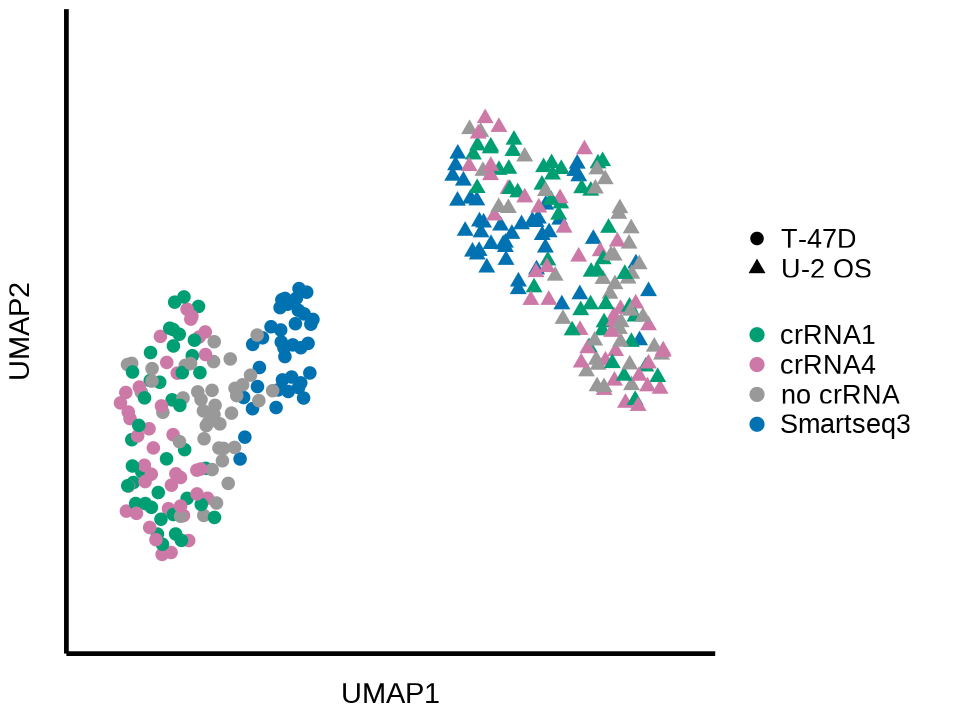

In [12]:
options(repr.plot.width = 8, repr.plot.height =6) 
df <- Embeddings(adata, "UMAP") %>% as.data.frame()
df$group <- adata@meta.data$cell_line
df$method <- adata@meta.data$method

ggplot(df, aes(-UMAP_1, UMAP_2, shape = group, color = method)) +
  geom_point(size = 3.2) +
  scale_shape_manual(values = c(16, 17), labels = c(
      "T47D" = "T-47D",
      "U2OS"  = "U-2 OS")) +

  scale_color_manual(
    values = c(
      "PIKcrRNA1" = "#009E73",
      "PIKcrRNA4" = "#CC79A7",
      "PIKnocrRNA" = "#999999",
      "Smartseq3" = "#0072B2"
    ),
    labels = c(
      "PIKcrRNA1" = "crRNA1",
      "PIKcrRNA4" = "crRNA4",
      "PIKnocrRNA" = "no crRNA",
      "Smartseq3" = "Smart-seq3"
    )
  ) +
  xlim(-15,15) +
  ylim(-9,9) +
  labs(x = "UMAP1", y = "UMAP2") +
  theme_minimal() +

  theme(
    axis.line = element_line(size = 1, color = "black"),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_blank(),
    axis.title.x = element_text(size = 22, margin = margin(t = 15), color = "black"), 
    axis.title.y = element_text(size = 22, margin = margin(r = 15), color = "black"),
    
  )
ggsave("data/UMAPvsSmartseq3.pdf", plot = last_plot(), width = 8, height = 6, units = "in")

In [13]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.67.0      showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9    
 [5] Matrix_1.6-5       dplyr_1.1.4        Seurat_5.3.0       SeuratObject_5.2.0
 [9] sp_2.2-0           stringr_1.5.2      ggplot2_3.5.2     

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0 